# Лабораторная работа №5: Анализ последовательностей



## Импорт библиотек и настройка окружения

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
import time
from collections import defaultdict
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
print("Все библиотеки загружены.")

Все библиотеки загружены.


---
## Загрузка и предобработка данных



In [6]:
import pandas as pd
raw_df = pd.read_excel('/content/online_retail_II.xlsx')
print(f"Размер: {raw_df.shape}")
raw_df.head()

Размер: (525461, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [7]:
# Предобработка
df = raw_df.copy()
df['Invoice'] = df['Invoice'].astype(str)
df = df[~df['Invoice'].str.startswith('C')]  # убираем возвраты
df = df.dropna(subset=['Customer ID', 'Description'])
df = df[df['Quantity'] > 0]
df = df[df['Price'] > 0]
df['Customer ID'] = df['Customer ID'].astype(int)

# Ограничиваем до топ-50 товаров для производительности
TOP_N = 50
top_items = df['Description'].value_counts().head(TOP_N).index.tolist()
df = df[df['Description'].isin(top_items)]

print(f"После фильтрации: {df.shape}")
print(f"Уникальных клиентов: {df['Customer ID'].nunique()}")
print(f"Уникальных товаров: {df['Description'].nunique()}")
print(f"Период: {df['InvoiceDate'].min()} — {df['InvoiceDate'].max()}")

После фильтрации: (48541, 8)
Уникальных клиентов: 3684
Уникальных товаров: 50
Период: 2009-12-01 07:45:00 — 2010-12-09 20:01:00


In [8]:
# Построение последовательностей клиентов
def build_customer_sequences(dataframe):
    """Строит словарь: customer_id -> [(date, frozenset_items), ...]"""
    seqs = {}
    for cid, grp in dataframe.groupby('Customer ID'):
        txns = []
        for inv, inv_grp in grp.groupby('Invoice'):
            dt = inv_grp['InvoiceDate'].min()
            items = frozenset(inv_grp['Description'].unique())
            txns.append((dt, items))
        txns.sort(key=lambda x: x[0])
        if len(txns) >= 2:
            seqs[cid] = txns
    return seqs

customer_sequences = build_customer_sequences(df)
print(f"Клиентов с >=2 транзакциями: {len(customer_sequences)}")

# Статистика
seq_lens = [len(v) for v in customer_sequences.values()]
print(f"Средняя длина последовательности: {np.mean(seq_lens):.1f}")
print(f"Медианная длина: {np.median(seq_lens):.0f}")
print(f"Макс длина: {max(seq_lens)}")

Клиентов с >=2 транзакциями: 2325
Средняя длина последовательности: 5.3
Медианная длина: 3
Макс длина: 146


---
## Задание 1. Реализация AprioriAll



In [9]:
def is_subsequence(pattern, sequence):
    """Проверяет, является ли pattern подпоследовательностью sequence.
    pattern и sequence — списки frozenset."""
    pi = 0
    for si in range(len(sequence)):
        if pi < len(pattern) and pattern[pi].issubset(sequence[si]):
            pi += 1
    return pi == len(pattern)


def apriori_all(customer_sequences, min_support, max_gap_days=None):

    n = len(customer_sequences)
    min_count = max(1, int(min_support * n))

    # Построение последовательностей (с учётом max_gap)
    sequences = {}
    for cid, txns in customer_sequences.items():
        sorted_txns = sorted(txns, key=lambda x: x[0])
        if max_gap_days is not None:
            all_seqs = []
            cur = [sorted_txns[0]]
            for i in range(1, len(sorted_txns)):
                gap = (sorted_txns[i][0] - cur[-1][0]).days
                if gap <= max_gap_days:
                    cur.append(sorted_txns[i])
                else:
                    seq = [items for _, items in cur]
                    if len(seq) >= 1:
                        all_seqs.append(seq)
                    cur = [sorted_txns[i]]
            seq = [items for _, items in cur]
            if len(seq) >= 1:
                all_seqs.append(seq)
            sequences[cid] = all_seqs
        else:
            sequences[cid] = [[items for _, items in sorted_txns]]

    # Фаза 1: частые 1-элементы
    item_count = defaultdict(int)
    for cid, seqs in sequences.items():
        seen = set()
        for seq in seqs:
            for itemset in seq:
                seen.update(itemset)
        for item in seen:
            item_count[item] += 1

    freq_items = {it for it, cnt in item_count.items() if cnt >= min_count}

    # Фильтрация последовательностей
    for cid in list(sequences.keys()):
        new_seqs = []
        for seq in sequences[cid]:
            new_seq = []
            for itemset in seq:
                flt = itemset & freq_items
                if flt:
                    new_seq.append(frozenset(flt))
            if new_seq:
                new_seqs.append(new_seq)
        sequences[cid] = new_seqs

    # Результаты: частые 1-последовательности
    all_frequent = {}
    for item in freq_items:
        pat = (frozenset([item]),)
        all_frequent[pat] = item_count[item] / n

    # Итеративная генерация
    current_patterns = list(all_frequent.keys())
    freq_1 = [p for p in all_frequent if len(p) == 1]
    k = 2

    while current_patterns and k <= 5:
        candidates = set()
        for pat in current_patterns:
            for ext in freq_1:
                new_pat = pat + ext
                candidates.add(new_pat)

        if not candidates:
            break

        new_frequent = []
        for cand in candidates:
            cand_list = list(cand)
            count = 0
            for cid, seqs in sequences.items():
                for seq in seqs:
                    if is_subsequence(cand_list, seq):
                        count += 1
                        break
            if count >= min_count:
                all_frequent[cand] = count / n
                new_frequent.append(cand)

        current_patterns = new_frequent
        k += 1
        print(f"  k={k-1}: найдено {len(new_frequent)} частых последовательностей")

    return all_frequent

print("Функция apriori_all() реализована.")

Функция apriori_all() реализована.


---
## Задание 2. Анализ реальных данных

### 2.1 Влияние минимальной поддержки



AprioriAll с min_sup=5%...
  k=2: найдено 289 частых последовательностей
  k=3: найдено 43 частых последовательностей
  k=4: найдено 3 частых последовательностей
  k=5: найдено 1 частых последовательностей
  Время: 45.5 сек, Всего шаблонов: 386
    Длина 1: 50
    Длина 2: 289
    Длина 3: 43
    Длина 4: 3
    Длина 5: 1

AprioriAll с min_sup=10%...
  k=2: найдено 12 частых последовательностей
  k=3: найдено 1 частых последовательностей
  k=4: найдено 1 частых последовательностей
  k=5: найдено 0 частых последовательностей
  Время: 8.2 сек, Всего шаблонов: 63
    Длина 1: 49
    Длина 2: 12
    Длина 3: 1
    Длина 4: 1

AprioriAll с min_sup=20%...
  k=2: найдено 1 частых последовательностей
  k=3: найдено 0 частых последовательностей
  Время: 0.2 сек, Всего шаблонов: 10
    Длина 1: 9
    Длина 2: 1


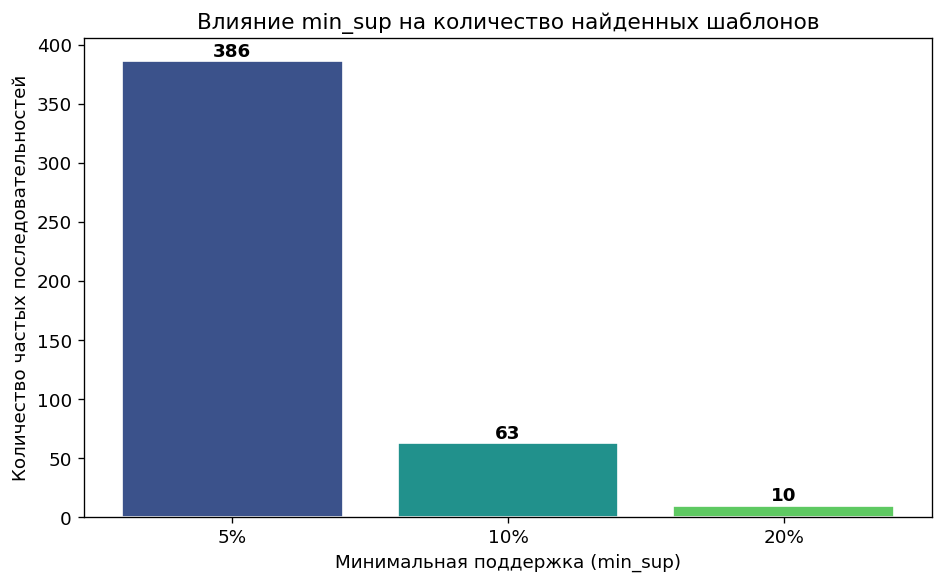


Вывод: с ростом min_sup количество шаблонов резко сокращается.
При низкой поддержке алгоритм находит множество редких паттернов,
но время работы значительно увеличивается — проблема масштабируемости.


In [10]:
support_levels = [0.05, 0.10, 0.20]
results_by_support = {}

for ms in support_levels:
    print(f"\nAprioriAll с min_sup={ms*100:.0f}%...")
    t0 = time.time()
    res = apriori_all(customer_sequences, min_support=ms)
    elapsed = time.time() - t0
    results_by_support[ms] = res
    total = len(res)
    by_len = defaultdict(int)
    for pat in res:
        by_len[len(pat)] += 1
    print(f"  Время: {elapsed:.1f} сек, Всего шаблонов: {total}")
    for l in sorted(by_len):
        print(f"    Длина {l}: {by_len[l]}")

# График
fig, ax = plt.subplots(figsize=(8, 5))
x = [f"{s*100:.0f}%" for s in support_levels]
y = [len(results_by_support[s]) for s in support_levels]
bars = ax.bar(x, y, color=sns.color_palette('viridis', len(x)), edgecolor='white')
for bar, val in zip(bars, y):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, str(val),
            ha='center', va='bottom', fontweight='bold')
ax.set_xlabel('Минимальная поддержка (min_sup)')
ax.set_ylabel('Количество частых последовательностей')
ax.set_title('Влияние min_sup на количество найденных шаблонов')
plt.tight_layout()
plt.show()

print("\nВывод: с ростом min_sup количество шаблонов резко сокращается.")
print("При низкой поддержке алгоритм находит множество редких паттернов,")
print("но время работы значительно увеличивается — проблема масштабируемости.")

### 2.2 Сравнение с ассоциативными правилами



In [11]:
# Классический Apriori для ассоциативных правил (без учёта порядка)
def apriori_classic(transactions, min_support):
    """Классический Apriori для наборов элементов."""
    n = len(transactions)
    min_count = max(1, int(min_support * n))

    # Частые 1-элементы
    item_counts = defaultdict(int)
    for t in transactions:
        for item in t:
            item_counts[frozenset([item])] += 1

    current = {it: cnt for it, cnt in item_counts.items() if cnt >= min_count}
    all_freq = {}
    for it, cnt in current.items():
        all_freq[tuple(sorted(it))] = cnt / n

    k = 2
    while current:
        prev_keys = [tuple(sorted(fs)) for fs in current.keys()]
        candidates = set()
        for i in range(len(prev_keys)):
            for j in range(i+1, len(prev_keys)):
                c = frozenset(prev_keys[i]) | frozenset(prev_keys[j])
                if len(c) == k:
                    candidates.add(c)

        if not candidates:
            break

        counts = defaultdict(int)
        for t in transactions:
            for c in candidates:
                if c.issubset(t):
                    counts[c] += 1

        current = {c: cnt for c, cnt in counts.items() if cnt >= min_count}
        for it, cnt in current.items():
            all_freq[tuple(sorted(it))] = cnt / n
        k += 1

    return all_freq


def generate_rules(freq_itemsets, min_confidence=0.1):
    """Генерация правил из частых наборов."""
    rules = []
    for itemset_t, support in freq_itemsets.items():
        itemset = frozenset(itemset_t)
        if len(itemset) < 2:
            continue
        for i in range(1, len(itemset)):
            for ant_t in combinations(sorted(itemset), i):
                ant = frozenset(ant_t)
                con = itemset - ant
                ant_key = tuple(sorted(ant))
                con_key = tuple(sorted(con))
                if ant_key not in freq_itemsets or con_key not in freq_itemsets:
                    continue
                sup_ant = freq_itemsets[ant_key]
                sup_con = freq_itemsets[con_key]
                conf = support / sup_ant
                if conf < min_confidence:
                    continue
                lift = conf / sup_con if sup_con > 0 else float('inf')
                rules.append({
                    'antecedent': ant_t, 'consequent': con_key,
                    'support': support, 'confidence': conf, 'lift': lift
                })
    return rules

# Собираем все транзакции (без учёта клиента и порядка)
all_transactions = []
for cid, txns in customer_sequences.items():
    for _, items in txns:
        filtered = items & set(top_items)
        if filtered:
            all_transactions.append(frozenset(filtered))

print(f"Всего транзакций для Apriori: {len(all_transactions)}")
freq_items_classic = apriori_classic(all_transactions, min_support=0.05)
rules = generate_rules(freq_items_classic, min_confidence=0.1)

# Топ-3 по lift
rules_sorted = sorted(rules, key=lambda x: x['lift'], reverse=True)[:3]
print("\nТоп-3 ассоциативных правила по Lift:")
for i, r in enumerate(rules_sorted, 1):
    print(f"  {i}. {set(r['antecedent'])} → {set(r['consequent'])}  "
          f"sup={r['support']:.3f}  conf={r['confidence']:.3f}  lift={r['lift']:.2f}")

# Проверяем наличие в последовательных шаблонах
seq_patterns = results_by_support.get(0.05, {})
print("\nПроверка: являются ли эти правила частыми последовательностями <{A},{B}>?")
for i, r in enumerate(rules_sorted, 1):
    for a_item in r['antecedent']:
        for c_item in r['consequent']:
            pat_fwd = (frozenset([a_item]), frozenset([c_item]))
            pat_rev = (frozenset([c_item]), frozenset([a_item]))
            fwd_sup = seq_patterns.get(pat_fwd, 0)
            rev_sup = seq_patterns.get(pat_rev, 0)
            print(f"  Правило {i}: <{{{a_item}}},{{{c_item}}}> sup={fwd_sup:.3f}, "
                  f"<{{{c_item}}},{{{a_item}}}> sup={rev_sup:.3f}")

print("\nВывод: ассоциативные правила не учитывают временной порядок.")
print("Товары, часто покупаемые вместе, не обязательно образуют")
print("частые последовательности — они могут покупаться одновременно.")

Всего транзакций для Apriori: 12394

Топ-3 ассоциативных правила по Lift:
  1. {'RED HANGING HEART T-LIGHT HOLDER'} → {'WHITE HANGING HEART T-LIGHT HOLDER'}  sup=0.053  conf=0.731  lift=3.25
  2. {'WHITE HANGING HEART T-LIGHT HOLDER'} → {'RED HANGING HEART T-LIGHT HOLDER'}  sup=0.053  conf=0.237  lift=3.25

Проверка: являются ли эти правила частыми последовательностями <{A},{B}>?
  Правило 1: <{RED HANGING HEART T-LIGHT HOLDER},{WHITE HANGING HEART T-LIGHT HOLDER}> sup=0.115, <{WHITE HANGING HEART T-LIGHT HOLDER},{RED HANGING HEART T-LIGHT HOLDER}> sup=0.122
  Правило 2: <{WHITE HANGING HEART T-LIGHT HOLDER},{RED HANGING HEART T-LIGHT HOLDER}> sup=0.122, <{RED HANGING HEART T-LIGHT HOLDER},{WHITE HANGING HEART T-LIGHT HOLDER}> sup=0.115

Вывод: ассоциативные правила не учитывают временной порядок.
Товары, часто покупаемые вместе, не обязательно образуют
частые последовательности — они могут покупаться одновременно.


### 2.3 Временные окна (max_gap)



In [12]:
print("AprioriAll БЕЗ ограничения max_gap (min_sup=10%)...")
t0 = time.time()
res_no_gap = apriori_all(customer_sequences, min_support=0.10)
t1 = time.time() - t0
print(f"  Время: {t1:.1f}с, Шаблонов: {len(res_no_gap)}")

print("\nAprioriAll С max_gap=7 дней (min_sup=10%)...")
t0 = time.time()
res_gap7 = apriori_all(customer_sequences, min_support=0.10, max_gap_days=7)
t2 = time.time() - t0
print(f"  Время: {t2:.1f}с, Шаблонов: {len(res_gap7)}")

# Сравнение
only_no_gap = set(res_no_gap.keys()) - set(res_gap7.keys())
only_gap7 = set(res_gap7.keys()) - set(res_no_gap.keys())
common = set(res_no_gap.keys()) & set(res_gap7.keys())

print(f"\nОбщих шаблонов: {len(common)}")
print(f"Только без max_gap: {len(only_no_gap)}")
print(f"Только с max_gap=7: {len(only_gap7)}")

if only_no_gap:
    print("\nПример шаблона, который ИСЧЕЗАЕТ при max_gap=7:")
    ex = list(only_no_gap)[0]
    pat_str = " → ".join([str(set(s)) for s in ex])
    print(f"  <{pat_str}> (sup={res_no_gap[ex]:.3f})")
    print("  Причина: транзакции этого шаблона разделены > 7 дней.")

if only_gap7:
    print("\nПример шаблона, который ПОЯВЛЯЕТСЯ при max_gap=7:")
    ex = list(only_gap7)[0]
    pat_str = " → ".join([str(set(s)) for s in ex])
    print(f"  <{pat_str}> (sup={res_gap7[ex]:.3f})")

AprioriAll БЕЗ ограничения max_gap (min_sup=10%)...
  k=2: найдено 12 частых последовательностей
  k=3: найдено 1 частых последовательностей
  k=4: найдено 1 частых последовательностей
  k=5: найдено 0 частых последовательностей
  Время: 8.2с, Шаблонов: 63

AprioriAll С max_gap=7 дней (min_sup=10%)...
  k=2: найдено 0 частых последовательностей
  Время: 9.9с, Шаблонов: 49

Общих шаблонов: 49
Только без max_gap: 14
Только с max_gap=7: 0

Пример шаблона, который ИСЧЕЗАЕТ при max_gap=7:
  <{'REGENCY CAKESTAND 3 TIER'} → {'REGENCY CAKESTAND 3 TIER'}> (sup=0.152)
  Причина: транзакции этого шаблона разделены > 7 дней.


### 2.4 Визуализация



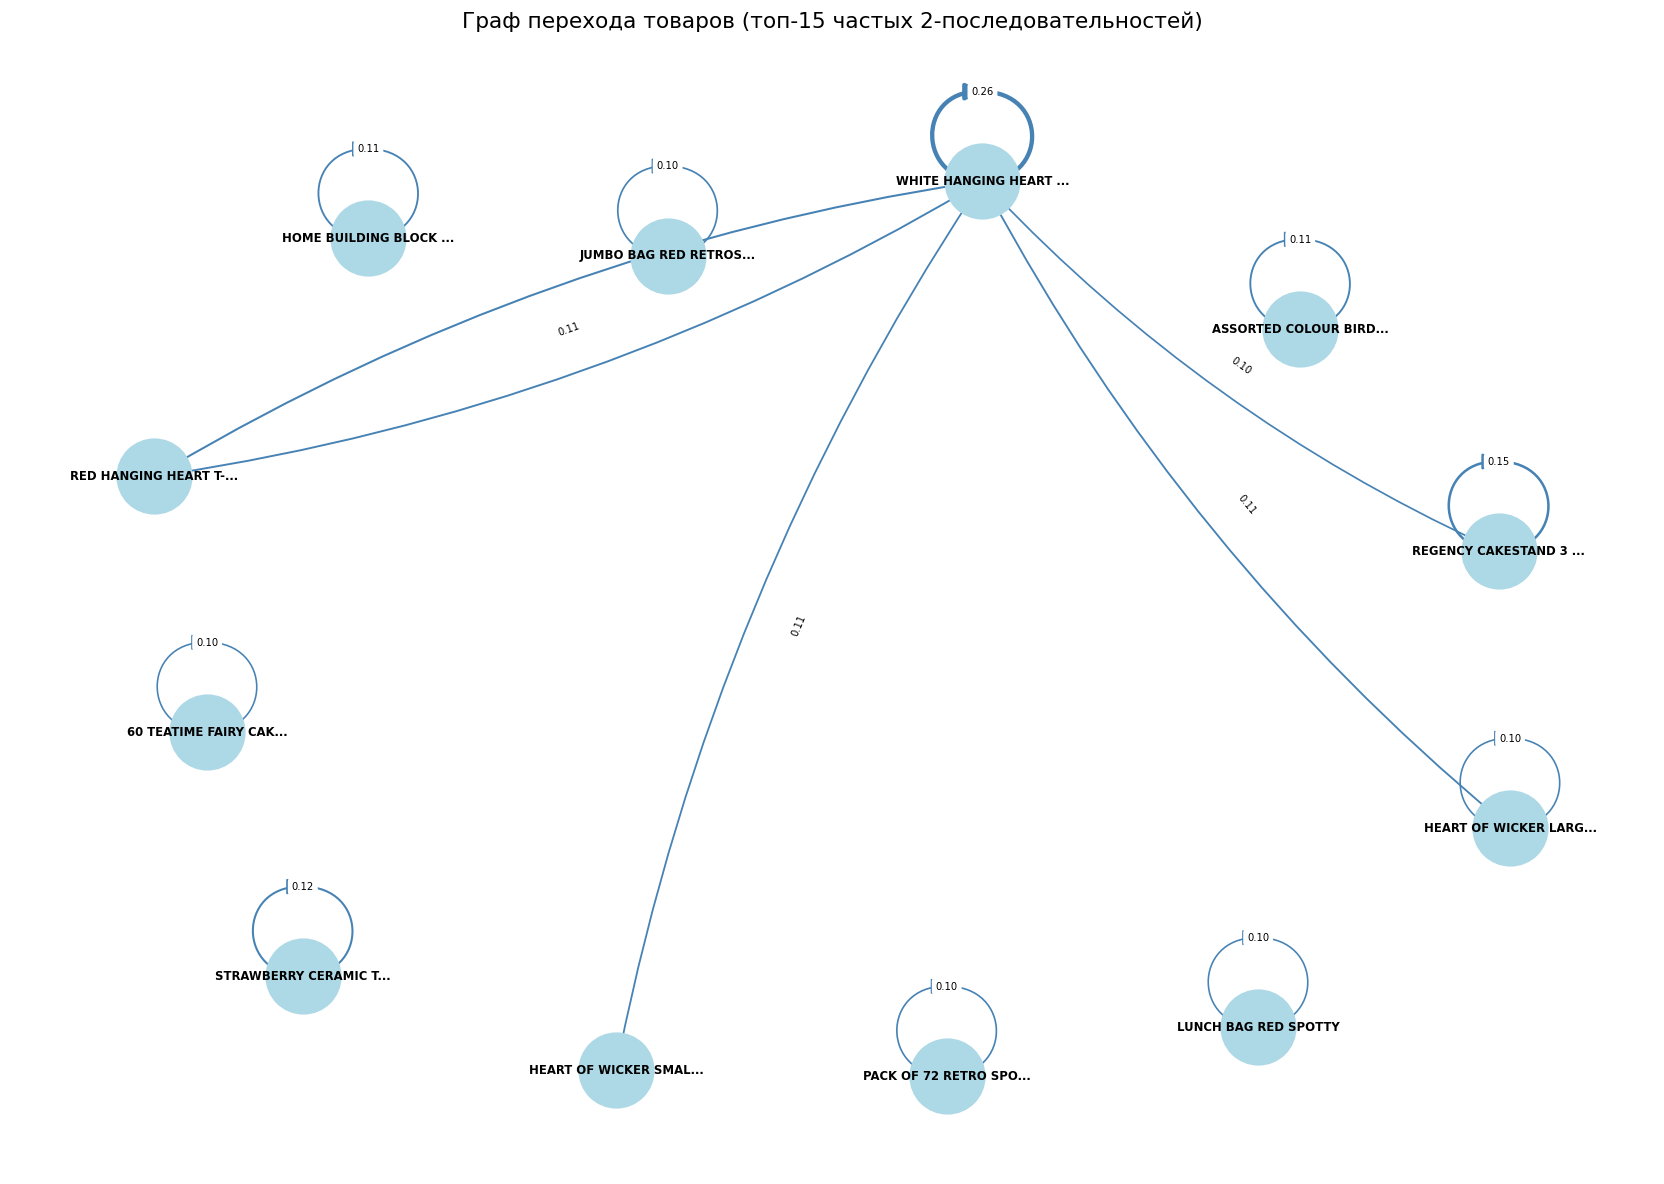


Наиболее частый шаблон: <{'WHITE HANGING HEART T-LIGHT HOLDER'} → {'WHITE HANGING HEART T-LIGHT HOLDER'}> (support=0.259)

Бизнес-гипотеза: клиенты, купившие первый товар, с высокой
вероятностью вернутся за вторым. Это можно использовать для
таргетированных email-рассылок и рекомендаций.


In [13]:
# Берём все 2-последовательности
seq_pats = results_by_support.get(0.05, res_no_gap)
two_seqs = {pat: sup for pat, sup in seq_pats.items() if len(pat) == 2}

if not two_seqs:
    print("Нет 2-последовательностей, используем min_sup=0.05")
else:
    # Строим граф переходов
    G = nx.DiGraph()
    for pat, sup in sorted(two_seqs.items(), key=lambda x: -x[1])[:15]:
        src = list(pat[0])[0] if len(pat[0]) == 1 else str(set(pat[0]))
        dst = list(pat[1])[0] if len(pat[1]) == 1 else str(set(pat[1]))
        # Сокращаем длинные названия
        src_short = src[:20] + '...' if len(str(src)) > 20 else str(src)
        dst_short = dst[:20] + '...' if len(str(dst)) > 20 else str(dst)
        G.add_edge(src_short, dst_short, weight=sup)

    fig, ax = plt.subplots(figsize=(14, 10))
    pos = nx.spring_layout(G, seed=42, k=2)

    weights = [G[u][v]['weight'] * 10 for u, v in G.edges()]

    nx.draw_networkx_nodes(G, pos, node_color='lightblue', node_size=2000, ax=ax)
    nx.draw_networkx_labels(G, pos, font_size=7, font_weight='bold', ax=ax)
    nx.draw_networkx_edges(G, pos, width=weights, edge_color='steelblue',
                           arrows=True, arrowsize=20, connectionstyle='arc3,rad=0.1', ax=ax)

    edge_labels = {(u, v): f"{G[u][v]['weight']:.2f}" for u, v in G.edges()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=6, ax=ax)

    ax.set_title('Граф перехода товаров (топ-15 частых 2-последовательностей)')
    ax.axis('off')
    plt.tight_layout()
    plt.show()

    # Интерпретация
    top_pat = max(two_seqs.items(), key=lambda x: x[1])
    pat_str = " → ".join([str(set(s)) for s in top_pat[0]])
    print(f"\nНаиболее частый шаблон: <{pat_str}> (support={top_pat[1]:.3f})")
    print("\nБизнес-гипотеза: клиенты, купившие первый товар, с высокой")
    print("вероятностью вернутся за вторым. Это можно использовать для")
    print("таргетированных email-рассылок и рекомендаций.")

---
## Задание 3. Сравнение алгоритмов SPM



In [14]:

from prefixspan import PrefixSpan

# Подготовка данных для PrefixSpan: список последовательностей
# Каждая последовательность = список элементов (items по порядку транзакций)
ps_sequences = []
for cid, txns in customer_sequences.items():
    seq = []
    for _, items in txns:
        for item in sorted(items):
            seq.append(item)
    ps_sequences.append(seq)

# Определяем min_count для 10% поддержки
min_sup_frac = 0.10
min_count_ps = max(1, int(min_sup_frac * len(ps_sequences)))

# PrefixSpan
print(f"Запуск PrefixSpan (min_count={min_count_ps}, {min_sup_frac*100:.0f}%)...")
t0 = time.time()
ps = PrefixSpan(ps_sequences)
ps.minlen = 1
ps.maxlen = 5
ps_result = ps.frequent(min_count_ps)
t_ps = time.time() - t0
print(f"  Время: {t_ps:.2f} сек, Шаблонов: {len(ps_result)}")

# AprioriAll
print(f"\nЗапуск AprioriAll (min_sup={min_sup_frac*100:.0f}%)...")
t0 = time.time()
aa_result = apriori_all(customer_sequences, min_support=min_sup_frac)
t_aa = time.time() - t0
print(f"  Время: {t_aa:.2f} сек, Шаблонов: {len(aa_result)}")

# Таблица сравнения
print("\n" + "="*65)
print(f"{'Алгоритм':<15} {'Время (сек)':<15} {'Кол-во шаблонов':<20} {'Примечание'}")
print("-"*65)
print(f"{'AprioriAll':<15} {t_aa:<15.2f} {len(aa_result):<20} {'наша реализация'}")
print(f"{'PrefixSpan':<15} {t_ps:<15.2f} {len(ps_result):<20} {'готовая библиотека'}")
print("="*65)

print("\nВывод:")
if t_ps < t_aa:
    print(f"PrefixSpan в {t_aa/max(t_ps,0.01):.1f}x быстрее AprioriAll.")
else:
    print(f"AprioriAll в {t_ps/max(t_aa,0.01):.1f}x быстрее PrefixSpan.")
print("PrefixSpan использует проекцию БД и не генерирует кандидатов,")
print("что делает его значительно эффективнее на больших данных.")
print("AprioriAll страдает от комбинаторного взрыва при генерации кандидатов.")

ModuleNotFoundError: No module named 'prefixspan'

---
## Задание 4. Предсказание следующего события



In [15]:
# Разделение по времени: 80% train, 20% test
all_dates = []
for cid, txns in customer_sequences.items():
    for dt, _ in txns:
        all_dates.append(dt)
all_dates.sort()
cutoff_idx = int(len(all_dates) * 0.8)
cutoff_date = all_dates[cutoff_idx]
print(f"Дата разделения: {cutoff_date}")

# Train/test sequences
train_sequences = {}
test_data = {}  # cid -> (last_train_items, next_test_items)

for cid, txns in customer_sequences.items():
    train_txns = [(dt, items) for dt, items in txns if dt <= cutoff_date]
    test_txns = [(dt, items) for dt, items in txns if dt > cutoff_date]

    if len(train_txns) >= 2:
        train_sequences[cid] = train_txns

    if len(train_txns) >= 1 and len(test_txns) >= 1:
        last_train = train_txns[-1][1]  # последняя транзакция train
        first_test = test_txns[0][1]    # первая транзакция test
        test_data[cid] = (last_train, first_test)

print(f"Train клиентов: {len(train_sequences)}")
print(f"Test клиентов (с данными для оценки): {len(test_data)}")

# Строим модель на train
print("\nОбучение AprioriAll на train...")
t0 = time.time()
train_patterns = apriori_all(train_sequences, min_support=0.05)
t_train = time.time() - t0
print(f"  Время: {t_train:.1f}с, Шаблонов: {len(train_patterns)}")

# Извлекаем 2-последовательности для предсказаний
prediction_model = {}  # item -> best_next_item (max support)
for pat, sup in train_patterns.items():
    if len(pat) == 2:
        for src_item in pat[0]:
            if src_item not in prediction_model or sup > prediction_model[src_item][1]:
                for dst_item in pat[1]:
                    prediction_model[src_item] = (dst_item, sup)

print(f"Правил предсказания: {len(prediction_model)}")

# Baseline: самый частый товар
item_freq = defaultdict(int)
for cid, txns in train_sequences.items():
    for _, items in txns:
        for item in items:
            item_freq[item] += 1
most_frequent_item = max(item_freq, key=item_freq.get)
print(f"Baseline — самый частый товар: {most_frequent_item}")

# Оценка
correct_seq = 0
correct_baseline = 0
total = 0

for cid, (last_items, next_items) in test_data.items():
    total += 1

    # Sequence-based prediction
    best_pred = None
    best_sup = -1
    for item in last_items:
        if item in prediction_model:
            pred, sup = prediction_model[item]
            if sup > best_sup:
                best_sup = sup
                best_pred = pred

    if best_pred and best_pred in next_items:
        correct_seq += 1

    # Baseline
    if most_frequent_item in next_items:
        correct_baseline += 1

acc_seq = correct_seq / max(total, 1)
acc_base = correct_baseline / max(total, 1)

print(f"\n{'='*50}")
print(f"{'Метод':<30} {'Accuracy@1'}")
print(f"{'-'*50}")
print(f"{'Последовательности':<30} {acc_seq:.4f} ({correct_seq}/{total})")
print(f"{'Глобальный топ-товар':<30} {acc_base:.4f} ({correct_baseline}/{total})")
print(f"{'='*50}")

if acc_seq > acc_base:
    print(f"\nВывод: учёт последовательности УЛУЧШАЕТ предсказание на {(acc_seq-acc_base)*100:.1f}%.")
else:
    print(f"\nВывод: baseline оказался не хуже. Это может быть связано с тем,")
    print("что самый частый товар покупается многими клиентами,")
    print("а последовательные паттерны слишком специфичны.")

Дата разделения: 2010-10-21 16:29:00
Train клиентов: 1955
Test клиентов (с данными для оценки): 1266

Обучение AprioriAll на train...
  k=2: найдено 302 частых последовательностей
  k=3: найдено 31 частых последовательностей
  k=4: найдено 1 частых последовательностей
  k=5: найдено 1 частых последовательностей
  Время: 39.1с, Шаблонов: 385
Правил предсказания: 44
Baseline — самый частый товар: WHITE HANGING HEART T-LIGHT HOLDER

Метод                          Accuracy@1
--------------------------------------------------
Последовательности             0.3712 (470/1266)
Глобальный топ-товар           0.1951 (247/1266)

Вывод: учёт последовательности УЛУЧШАЕТ предсказание на 17.6%.


---
## Задание 5. Контрастные последовательности



In [16]:
# Вычисляем суммарную выручку по клиентам
revenue = df.groupby('Customer ID').apply(
    lambda x: (x['Quantity'] * x['Price']).sum()
).reset_index()
revenue.columns = ['Customer ID', 'total_revenue']

# Порог: 75-й перцентиль
threshold = revenue['total_revenue'].quantile(0.75)
print(f"Порог High Value (75-й перцентиль): {threshold:.2f}")

high_value_ids = set(revenue[revenue['total_revenue'] >= threshold]['Customer ID'])
low_value_ids = set(revenue[revenue['total_revenue'] < threshold]['Customer ID'])

# Разделяем последовательности
high_seqs = {cid: txns for cid, txns in customer_sequences.items() if cid in high_value_ids}
low_seqs = {cid: txns for cid, txns in customer_sequences.items() if cid in low_value_ids}
print(f"High Value клиентов: {len(high_seqs)}")
print(f"Low Value клиентов: {len(low_seqs)}")

# Ищем частые последовательности для каждого класса
min_sup_contrast = 0.10
print(f"\nAprioriAll для High Value (min_sup={min_sup_contrast*100:.0f}%)...")
high_patterns = apriori_all(high_seqs, min_support=min_sup_contrast)
print(f"  Шаблонов: {len(high_patterns)}")

print(f"AprioriAll для Low Value (min_sup={min_sup_contrast*100:.0f}%)...")
low_patterns = apriori_all(low_seqs, min_support=min_sup_contrast)
print(f"  Шаблонов: {len(low_patterns)}")

# Контрастность
contrast_scores = []
for pat, h_sup in high_patterns.items():
    l_sup = low_patterns.get(pat, 0)
    contrast = h_sup - l_sup
    contrast_scores.append((pat, h_sup, l_sup, contrast))

contrast_scores.sort(key=lambda x: -x[3])

print(f"\nТоп-5 контрастных последовательностей (чаще у High Value):")
print(f"{'Шаблон':<50} {'HV sup':>8} {'LV sup':>8} {'Контраст':>10}")
print("-" * 80)
for pat, h_s, l_s, ctr in contrast_scores[:5]:
    pat_str = " → ".join([str(set(s)) for s in pat])
    print(f"<{pat_str[:47]:<47}> {h_s:>8.3f} {l_s:>8.3f} {ctr:>+10.3f}")

print("\nГипотезы:")
for i, (pat, h_s, l_s, ctr) in enumerate(contrast_scores[:3], 1):
    items = [list(s)[0] if len(s)==1 else str(set(s)) for s in pat]
    if len(items) >= 2:
        print(f"  {i}. «Клиенты, купившие {items[0]}, а затем {items[1]},")
        print(f"     с большей вероятностью станут высокодоходными» (контраст={ctr:+.3f})")

Порог High Value (75-й перцентиль): 298.83
High Value клиентов: 904
Low Value клиентов: 1421

AprioriAll для High Value (min_sup=10%)...
  k=2: найдено 316 частых последовательностей
  k=3: найдено 95 частых последовательностей
  k=4: найдено 9 частых последовательностей
  k=5: найдено 1 частых последовательностей
  Шаблонов: 470
AprioriAll для Low Value (min_sup=10%)...
  k=2: найдено 2 частых последовательностей
  k=3: найдено 0 частых последовательностей
  Шаблонов: 37

Топ-5 контрастных последовательностей (чаще у High Value):
Шаблон                                               HV sup   LV sup   Контраст
--------------------------------------------------------------------------------
<{'WHITE HANGING HEART T-LIGHT HOLDER'} → {'WHIT>    0.325    0.000     +0.325
<{'LUNCH BAG CARS BLUE'}                        >    0.275    0.000     +0.275
<{'REGENCY CAKESTAND 3 TIER'} → {'REGENCY CAKEST>    0.273    0.000     +0.273
<{'WHITE HANGING HEART T-LIGHT HOLDER'} → {'WHIT>    0.420    0.1

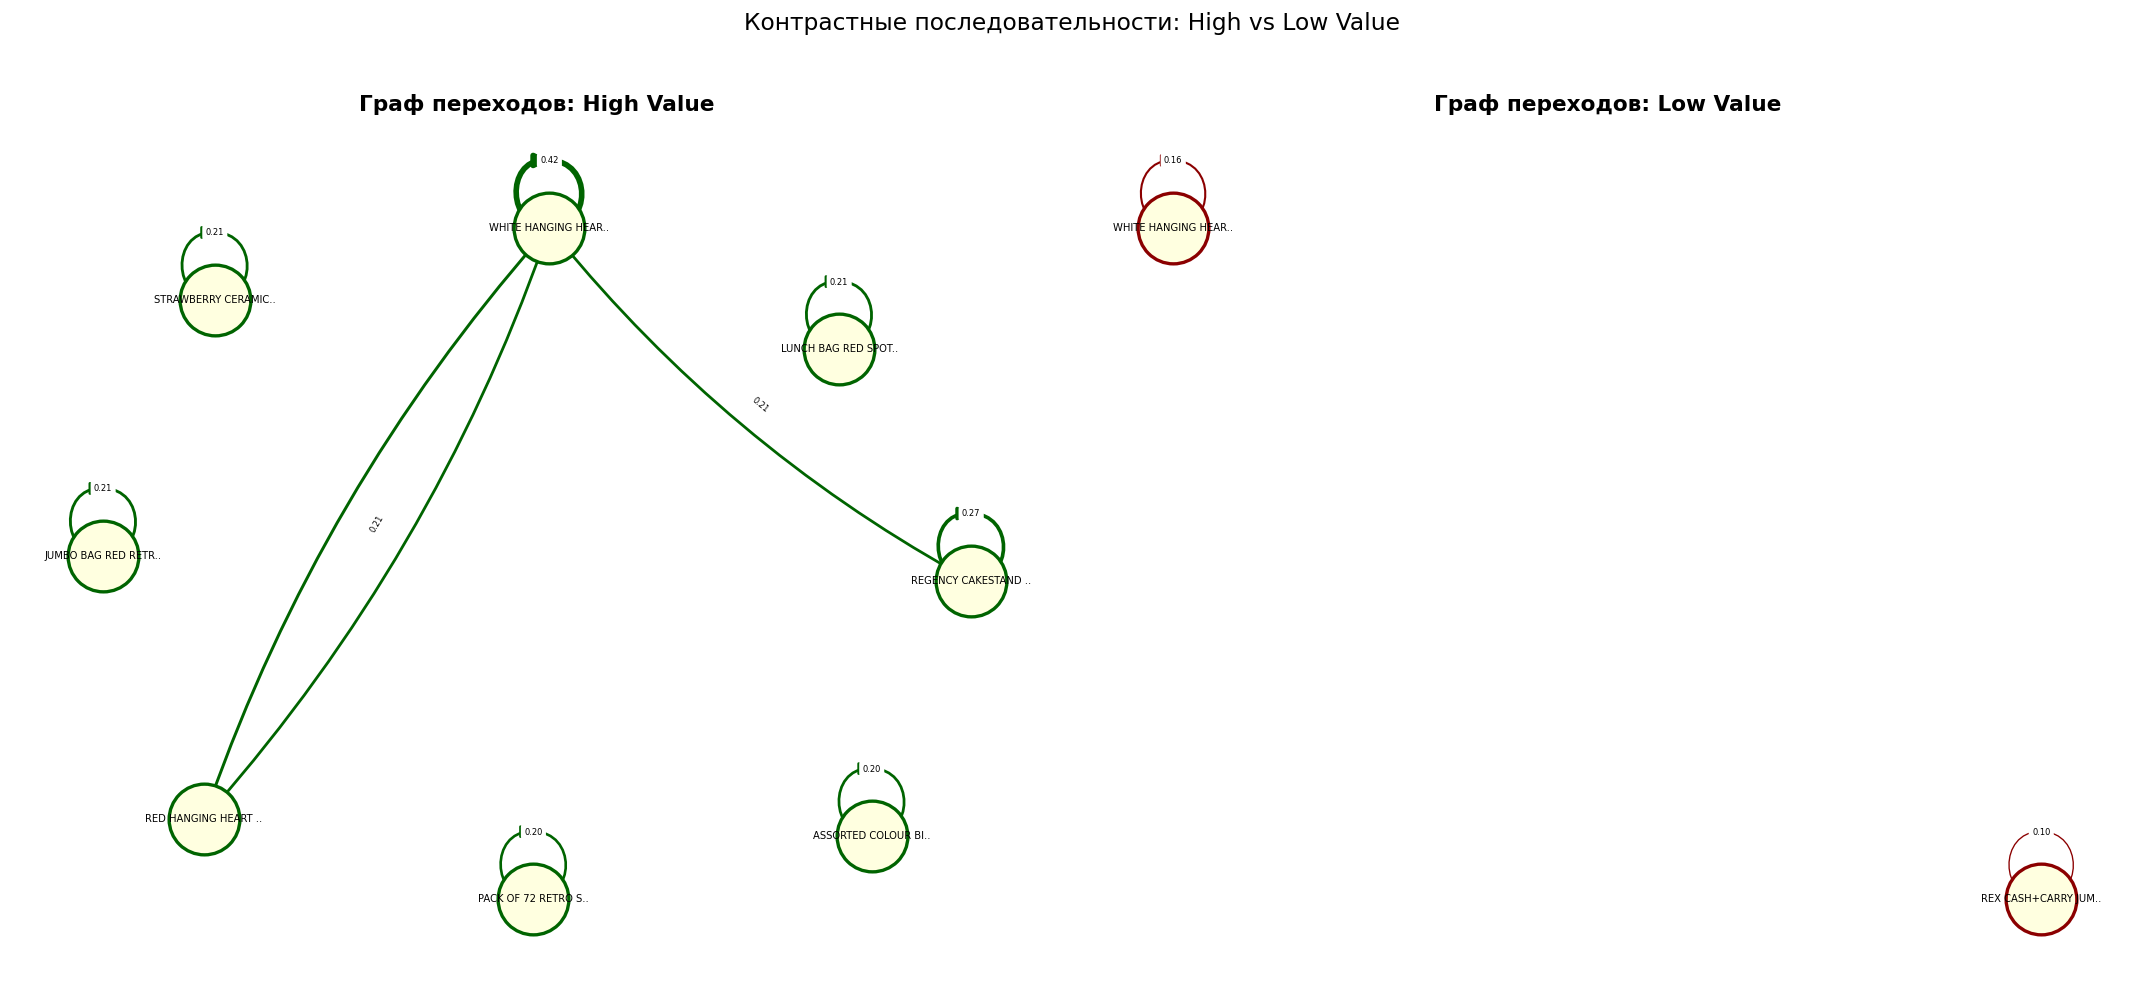

In [17]:
# Визуализация: графы переходов для High и Low Value
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

for ax, patterns, title, color in [
    (axes[0], high_patterns, 'High Value', 'darkgreen'),
    (axes[1], low_patterns, 'Low Value', 'darkred')
]:
    two_seqs = {p: s for p, s in patterns.items() if len(p) == 2}
    G = nx.DiGraph()
    for pat, sup in sorted(two_seqs.items(), key=lambda x: -x[1])[:10]:
        src = list(pat[0])[0] if len(pat[0])==1 else str(set(pat[0]))
        dst = list(pat[1])[0] if len(pat[1])==1 else str(set(pat[1]))
        s = src[:18] + '..' if len(str(src)) > 18 else str(src)
        d = dst[:18] + '..' if len(str(dst)) > 18 else str(dst)
        G.add_edge(s, d, weight=sup)

    if len(G.nodes) > 0:
        pos = nx.spring_layout(G, seed=42, k=2)
        weights = [G[u][v]['weight'] * 8 for u, v in G.edges()]
        nx.draw_networkx_nodes(G, pos, node_color='lightyellow', node_size=1800,
                               edgecolors=color, linewidths=2, ax=ax)
        nx.draw_networkx_labels(G, pos, font_size=6, ax=ax)
        nx.draw_networkx_edges(G, pos, width=weights, edge_color=color,
                               arrows=True, arrowsize=15,
                               connectionstyle='arc3,rad=0.1', ax=ax)
        elabels = {(u,v): f"{G[u][v]['weight']:.2f}" for u,v in G.edges()}
        nx.draw_networkx_edge_labels(G, pos, elabels, font_size=5, ax=ax)
    ax.set_title(f'Граф переходов: {title}', fontsize=13, fontweight='bold')
    ax.axis('off')

plt.suptitle('Контрастные последовательности: High vs Low Value', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()


---
## Выводы

1. **AprioriAll** успешно реализован с нуля и проверен на синтетических данных.
2. С ростом `min_sup` количество шаблонов резко сокращается — наблюдается типичный экспоненциальный характер.
3. **Ассоциативные правила** не учитывают временной порядок — товары, часто покупаемые вместе, не обязательно образуют последовательности.
4. **Временные окна** (`max_gap`) позволяют фильтровать слишком далёкие по времени паттерны.
5. **PrefixSpan** значительно эффективнее AprioriAll благодаря проекции базы данных.
6. **Предсказание** на основе последовательностей может как улучшить, так и не улучшить baseline — зависит от характера данных.
7. **Контрастные последовательности** — мощный инструмент для сегментации клиентов и выявления паттернов, характерных для ценных клиентов.